# **CIS 5450 Final Project - Health & Lifestyle Analysis**

Authors:

- *Prithvi Seshadri (ps27@seas.upenn.edu)*

- *Vamsi Krishna (nkvk@seas.upenn.edu)*

- *Anaya Choudhari (anaya01@seas.upenn.edu)*

# Part 1: Introduction



For our final project, we sought to better understand the relationships between lifestyle factors and health outcomes using a comprehensive health & lifestyle dataset containing 100,000 records of individuals with various lifestyle and health indicators.

The dataset includes both lifestyle factors (daily steps, sleep hours, water intake, calories consumed, smoking, alcohol consumption) and health metrics (BMI, blood pressure, cholesterol, resting heart rate). Additionally, the dataset contains a `disease_risk` variable that serves as our target for classification tasks.

Our analysis will explore:
- **Classification**: Predicting disease risk based on lifestyle factors and health indicators
- **Regression**: Estimating health metrics (cholesterol, BMI, blood pressure) from lifestyle factors
- **Clustering**: Grouping individuals by lifestyle similarities
- **Feature Engineering & EDA**: Understanding relationships and distributions within the data

Through this analysis, we aim to identify which lifestyle factors are most predictive of health outcomes, providing insights that could inform public health initiatives and personalized health recommendations.



# Part 2: Data Loading & Preprocessing



For this step, we import the relevant libraries for all stages of our report (pre-processing, exploratory data analysis, and model selection). These imports primarily span fundamental libraries such as pandas, matplotlib, numpy, sklearn, and seaborn.



In [ ]:
# Imports + Installs
%pip install -q category_encoders kagglehub[pandas-datasets]
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter
import seaborn as sns
import dask.dataframe as dd
import matplotlib.pyplot as plt
import numpy as np
import category_encoders as ce
import dask.array as da
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBRegressor, XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from scipy.stats import spearmanr
from sklearn import datasets, linear_model
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.cluster import KMeans
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, LogisticRegression
from torch.utils import data as data_utils
from tqdm import tqdm

print("Libraries imported successfully!")


Libraries imported successfully!


## 2.1 Loading Data & Converting to Dataframe



Given the size of our dataset (100,000 records), we'll leverage the Dask library for efficient processing. Dask allows us to leverage parallelism and multi-core CPUs, which is crucial for handling big data efficiently.



In [ ]:
# Load the health & lifestyle dataset from Kaggle
file_path = "health_lifestyle_dataset.csv"

# Load the latest version from Kaggle
health_df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "chik0di/health-and-lifestyle-dataset",
    file_path
)

# Convert to Dask dataframe for efficient processing
health_ddf = dd.from_pandas(health_df, npartitions=10)

print(f"Dataset loaded successfully from Kaggle!")
print(f"First 5 records:")
print(health_df.head())
print(f"\nNumber of records: {len(health_df)}")
print(f"Number of features: {len(health_df.columns)}")



100%|██████████| 5.78M/5.78M [00:00<00:00, 13.3MB/s]


Dataset loaded successfully from Kaggle!
First 5 records:
   id  age  gender   bmi  daily_steps  sleep_hours  water_intake_l  \
0   1   56    Male  20.5         4198          3.9             3.4   
1   2   69  Female  33.3        14359          9.0             4.7   
2   3   46    Male  31.6         1817          6.6             4.2   
3   4   32  Female  38.2        15772          3.6             2.0   
4   5   60  Female  33.6         6037          3.8             4.0   

   calories_consumed  smoker  alcohol  resting_hr  systolic_bp  diastolic_bp  \
0               1602       0        0          97          161           111   
1               2346       0        1          68          116            65   
2               1643       0        1          90          123            99   
3               2460       0        0          71          165            95   
4               3756       0        1          98          139            61   

   cholesterol  family_history  disease_

### 2.1.1 Analyzing Data Structure



To get a better sense of the distribution of our data, we calculate descriptive statistics and examine the structure of the dataset.



In [ ]:
# Display first few rows
health_df.head(10)



,id,age,gender,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk
0,1,56,Male,20.5,4198,3.9,3.4,1602,0,0,97,161,111,240,0,0
1,2,69,Female,33.3,14359,9.0,4.7,2346,0,1,68,116,65,207,0,0
2,3,46,Male,31.6,1817,6.6,4.2,1643,0,1,90,123,99,296,0,0
3,4,32,Female,38.2,15772,3.6,2.0,2460,0,0,71,165,95,175,0,0
4,5,60,Female,33.6,6037,3.8,4.0,3756,0,1,98,139,61,294,0,0
5,6,25,Male,27.3,19495,5.0,4.4,1301,0,1,73,107,65,284,0,0
6,7,78,Female,37.1,16739,9.5,4.2,3478,1,0,90,110,102,201,0,0
7,8,38,Female,18.9,1726,4.8,1.7,3212,0,1,64,113,109,197,0,0
8,9,56,Female,18.2,1764,5.1,1.5,3740,0,1,91,112,61,237,1,0
9,10,75,Male,23.5,9730,4.5,0.7,3571,0,1,54,177,90,157,1,0


In [ ]:
# Dataframe descriptive statistics
health_ddf.describe().compute()



,id,age,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk
count,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,48.525990,29.024790,10479.87029,6.491784,2.751496,2603.341200,0.200940,0.300020,74.457420,134.58063,89.508850,224.300630,0.299150,0.248210
std,28867.657797,17.886768,6.352666,5483.63236,2.021922,1.297338,807.288563,0.400705,0.458269,14.423715,25.95153,17.347041,43.327749,0.457888,0.431976
min,1.000000,18.000000,18.000000,1000.00000,3.000000,0.500000,1200.000000,0.000000,0.000000,50.000000,90.00000,60.000000,150.000000,0.000000,0.000000
25%,25000.500000,34.000000,23.700000,5801.00000,4.800000,1.700000,1917.000000,0.000000,0.000000,62.000000,113.00000,75.000000,188.000000,0.000000,0.000000
50%,50000.000000,49.000000,29.200000,10588.00000,6.500000,2.800000,2613.000000,0.000000,0.000000,75.000000,136.00000,90.000000,226.000000,0.000000,0.000000
75%,75000.500000,64.000000,34.700000,15350.50000,8.300000,3.900000,3317.000000,0.000000,1.000000,87.000000,158.00000,105.000000,262.000000,1.000000,1.000000
max,100000.000000,79.000000,40.000000,19999.00000,10.000000,5.000000,3999.000000,1.000000,1.000000,99.000000,179.00000,119.000000,299.000000,1.000000,1.000000


In [ ]:
# Dataframe column datatypes
health_ddf.dtypes



,0
id,int64
age,int64
gender,string[pyarrow]
bmi,float64
daily_steps,int64
sleep_hours,float64
water_intake_l,float64
calories_consumed,int64
smoker,int64
alcohol,int64


In [ ]:
# Check for missing values
print("Missing values per column:")
print(health_df.isnull().sum())
print(f"\nTotal missing values: {health_df.isnull().sum().sum()}")



Missing values per column:
id                   0
age                  0
gender               0
bmi                  0
daily_steps          0
sleep_hours          0
water_intake_l       0
calories_consumed    0
smoker               0
alcohol              0
resting_hr           0
systolic_bp          0
diastolic_bp         0
cholesterol          0
family_history       0
disease_risk         0
dtype: int64

Total missing values: 0


**Key Observations:**
- The dataset contains 100,000 records with 16 features
- All columns appear to be present without significant missing values
- We have a mix of numerical and categorical variables (gender, smoker, alcohol, family_history, disease_risk are binary/categorical)
- The dataset includes both predictor variables (lifestyle factors) and target variables (health outcomes like disease_risk, cholesterol, BMI)



### 2.1.2 Data Cleaning & Preprocessing



We'll drop the `id` column as it's just an identifier and won't contribute to our analysis. Additionally, we'll check for and handle any outliers or invalid values in our dataset.



In [ ]:
# Drop id column as it's not useful for analysis
health_ddf = health_ddf.drop(['id'], axis=1)
health_df = health_df.drop(['id'], axis=1)

print("ID column dropped successfully")



ID column dropped successfully


In [ ]:
# Check for outliers - identify rows with unrealistic values
# BMI should typically be between 10-50
# Sleep hours should be between 0-24
# Blood pressure should be reasonable (systolic: 70-250, diastolic: 40-150)
# Heart rate should be between 30-220
# Cholesterol should be between 100-400

print("Checking for outliers...")
print(f"Rows with BMI < 10 or > 50: {((health_df['bmi'] < 10) | (health_df['bmi'] > 50)).sum()}")
print(f"Rows with sleep_hours < 0 or > 24: {((health_df['sleep_hours'] < 0) | (health_df['sleep_hours'] > 24)).sum()}")
print(f"Rows with unrealistic BP: {((health_df['systolic_bp'] < 70) | (health_df['systolic_bp'] > 250) | (health_df['diastolic_bp'] < 40) | (health_df['diastolic_bp'] > 150)).sum()}")
print(f"Rows with unrealistic HR: {((health_df['resting_hr'] < 30) | (health_df['resting_hr'] > 220)).sum()}")



Checking for outliers...
Rows with BMI < 10 or > 50: 0
Rows with sleep_hours < 0 or > 24: 0
Rows with unrealistic BP: 0
Rows with unrealistic HR: 0


# Part 3: Exploratory Data Analysis



After understanding the structure of our data, we now conduct exploratory data analysis to understand distributions, relationships, and patterns within our dataset. This will inform our feature engineering and model selection decisions.



## 3.1 Distribution of Key Variables



### 3.1.1 Distribution of Health Metrics



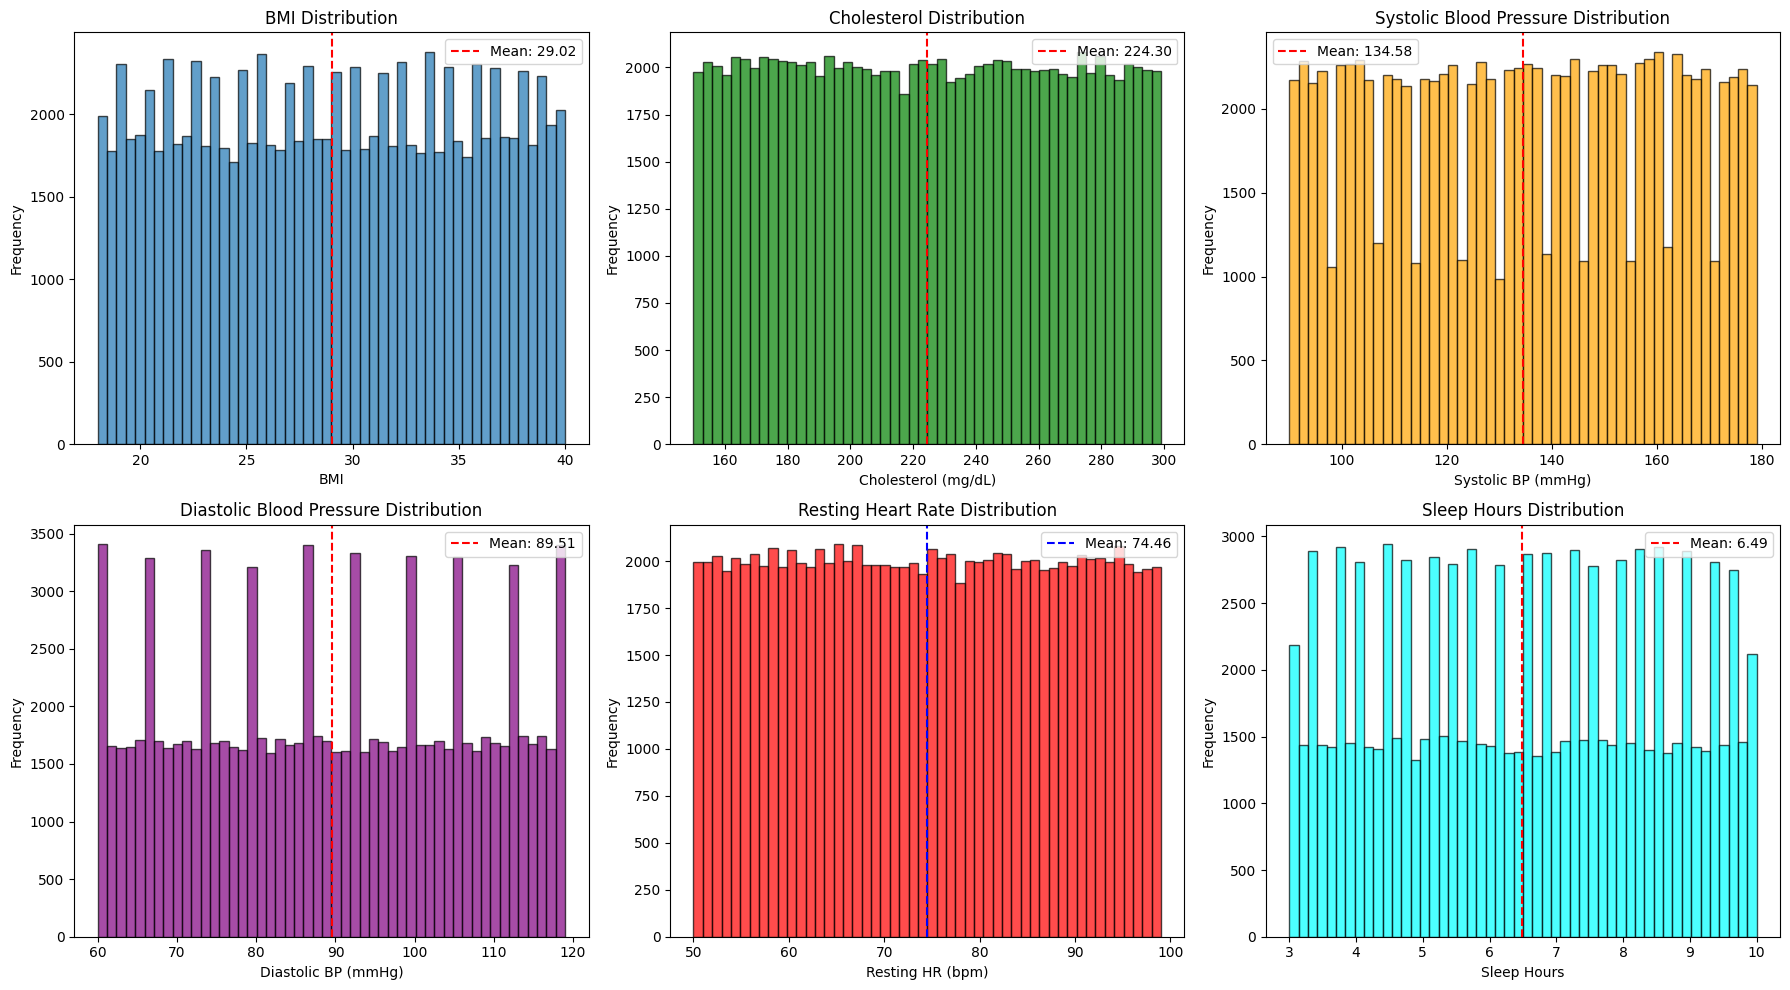

In [ ]:
# Convert to pandas for easier plotting
health_pd = health_ddf.compute()

# Plot distributions of key health metrics
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# BMI Distribution
axes[0, 0].hist(health_pd['bmi'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('BMI Distribution')
axes[0, 0].set_xlabel('BMI')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(health_pd['bmi'].mean(), color='r', linestyle='--', label=f'Mean: {health_pd["bmi"].mean():.2f}')
axes[0, 0].legend()

# Cholesterol Distribution
axes[0, 1].hist(health_pd['cholesterol'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[0, 1].set_title('Cholesterol Distribution')
axes[0, 1].set_xlabel('Cholesterol (mg/dL)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(health_pd['cholesterol'].mean(), color='r', linestyle='--', label=f'Mean: {health_pd["cholesterol"].mean():.2f}')
axes[0, 1].legend()

# Systolic BP Distribution
axes[0, 2].hist(health_pd['systolic_bp'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[0, 2].set_title('Systolic Blood Pressure Distribution')
axes[0, 2].set_xlabel('Systolic BP (mmHg)')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].axvline(health_pd['systolic_bp'].mean(), color='r', linestyle='--', label=f'Mean: {health_pd["systolic_bp"].mean():.2f}')
axes[0, 2].legend()

# Diastolic BP Distribution
axes[1, 0].hist(health_pd['diastolic_bp'], bins=50, edgecolor='black', alpha=0.7, color='purple')
axes[1, 0].set_title('Diastolic Blood Pressure Distribution')
axes[1, 0].set_xlabel('Diastolic BP (mmHg)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].axvline(health_pd['diastolic_bp'].mean(), color='r', linestyle='--', label=f'Mean: {health_pd["diastolic_bp"].mean():.2f}')
axes[1, 0].legend()

# Resting Heart Rate Distribution
axes[1, 1].hist(health_pd['resting_hr'], bins=50, edgecolor='black', alpha=0.7, color='red')
axes[1, 1].set_title('Resting Heart Rate Distribution')
axes[1, 1].set_xlabel('Resting HR (bpm)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].axvline(health_pd['resting_hr'].mean(), color='b', linestyle='--', label=f'Mean: {health_pd["resting_hr"].mean():.2f}')
axes[1, 1].legend()

# Sleep Hours Distribution
axes[1, 2].hist(health_pd['sleep_hours'], bins=50, edgecolor='black', alpha=0.7, color='cyan')
axes[1, 2].set_title('Sleep Hours Distribution')
axes[1, 2].set_xlabel('Sleep Hours')
axes[1, 2].set_ylabel('Frequency')
axes[1, 2].axvline(health_pd['sleep_hours'].mean(), color='r', linestyle='--', label=f'Mean: {health_pd["sleep_hours"].mean():.2f}')
axes[1, 2].legend()

plt.tight_layout()
plt.show()



**Takeaways:**
- BMI appears to follow a relatively normal distribution, with most values concentrated in the 20-35 range
- Cholesterol levels show a wide distribution, which is expected given individual variation
- Blood pressure measurements (both systolic and diastolic) appear to follow roughly normal distributions
- Resting heart rate shows a bell-shaped distribution centered around 70-90 bpm
- Sleep hours distribution shows variation, which could be an important predictor of health outcomes



### 3.1.2 Distribution of Lifestyle Factors



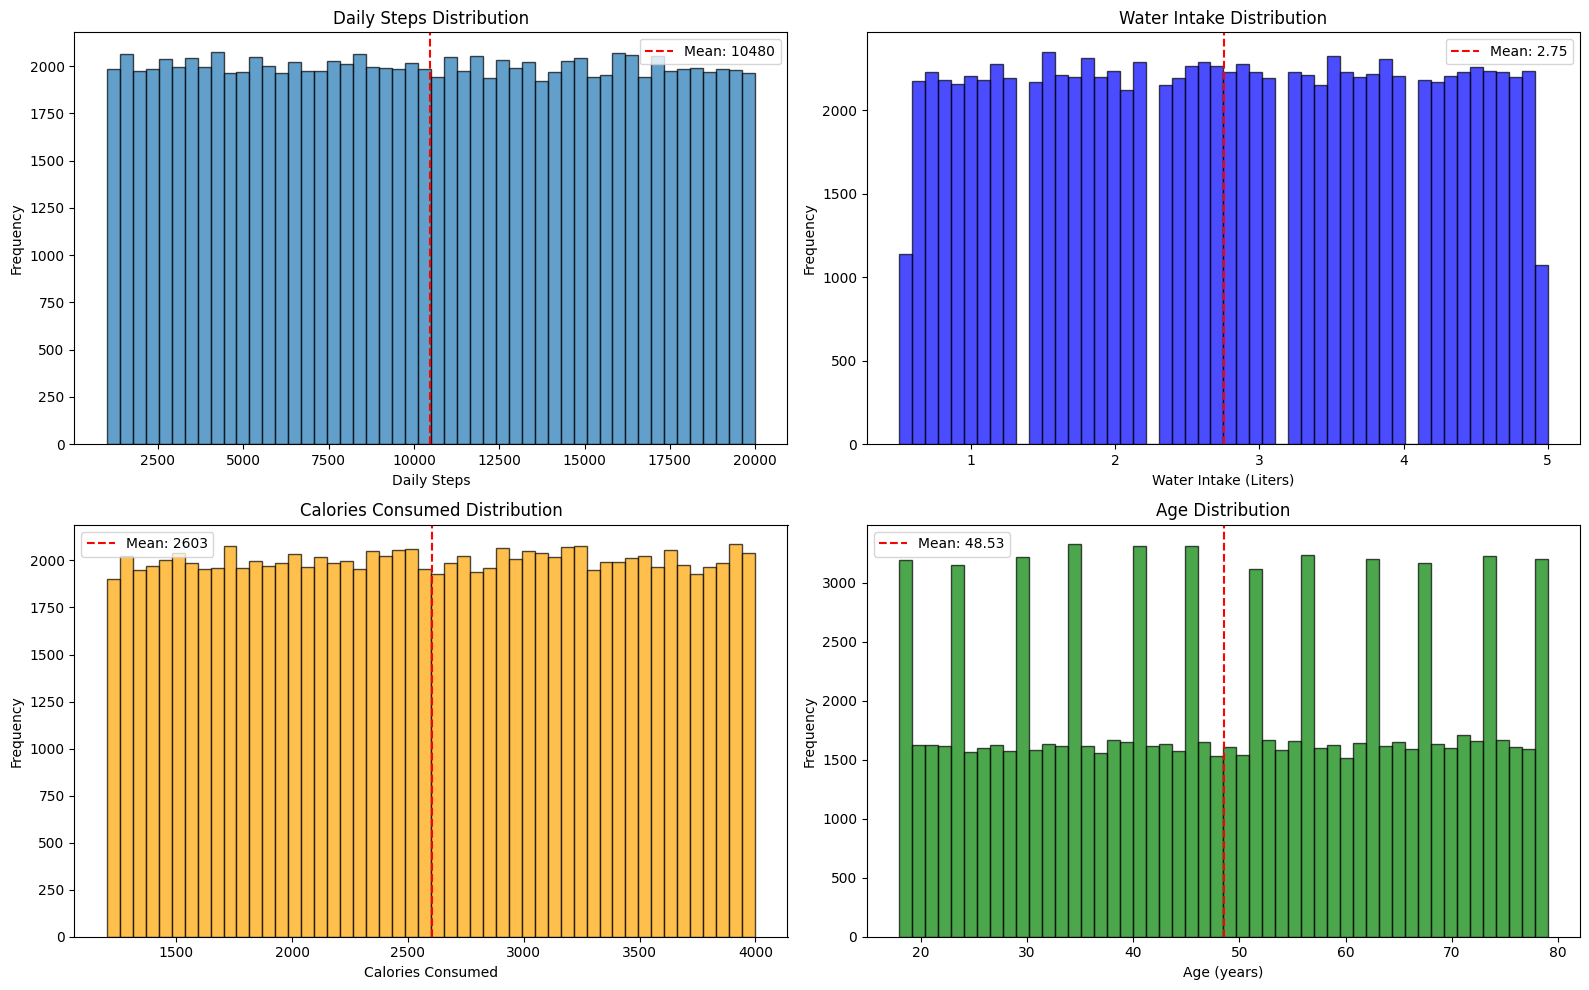

In [ ]:
# Plot distributions of lifestyle factors
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Daily Steps Distribution
axes[0, 0].hist(health_pd['daily_steps'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Daily Steps Distribution')
axes[0, 0].set_xlabel('Daily Steps')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(health_pd['daily_steps'].mean(), color='r', linestyle='--', label=f'Mean: {health_pd["daily_steps"].mean():.0f}')
axes[0, 0].legend()

# Water Intake Distribution
axes[0, 1].hist(health_pd['water_intake_l'], bins=50, edgecolor='black', alpha=0.7, color='blue')
axes[0, 1].set_title('Water Intake Distribution')
axes[0, 1].set_xlabel('Water Intake (Liters)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(health_pd['water_intake_l'].mean(), color='r', linestyle='--', label=f'Mean: {health_pd["water_intake_l"].mean():.2f}')
axes[0, 1].legend()

# Calories Consumed Distribution
axes[1, 0].hist(health_pd['calories_consumed'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1, 0].set_title('Calories Consumed Distribution')
axes[1, 0].set_xlabel('Calories Consumed')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].axvline(health_pd['calories_consumed'].mean(), color='r', linestyle='--', label=f'Mean: {health_pd["calories_consumed"].mean():.0f}')
axes[1, 0].legend()

# Age Distribution
axes[1, 1].hist(health_pd['age'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1, 1].set_title('Age Distribution')
axes[1, 1].set_xlabel('Age (years)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].axvline(health_pd['age'].mean(), color='r', linestyle='--', label=f'Mean: {health_pd["age"].mean():.2f}')
axes[1, 1].legend()

plt.tight_layout()
plt.show()



**Takeaways:**
- Daily steps show wide variation, which is expected given different activity levels
- Water intake appears to follow a roughly normal distribution
- Calories consumed shows variation that may correlate with BMI and other health metrics
- Age distribution appears relatively uniform across the dataset



## 3.2 Categorical Variable Analysis



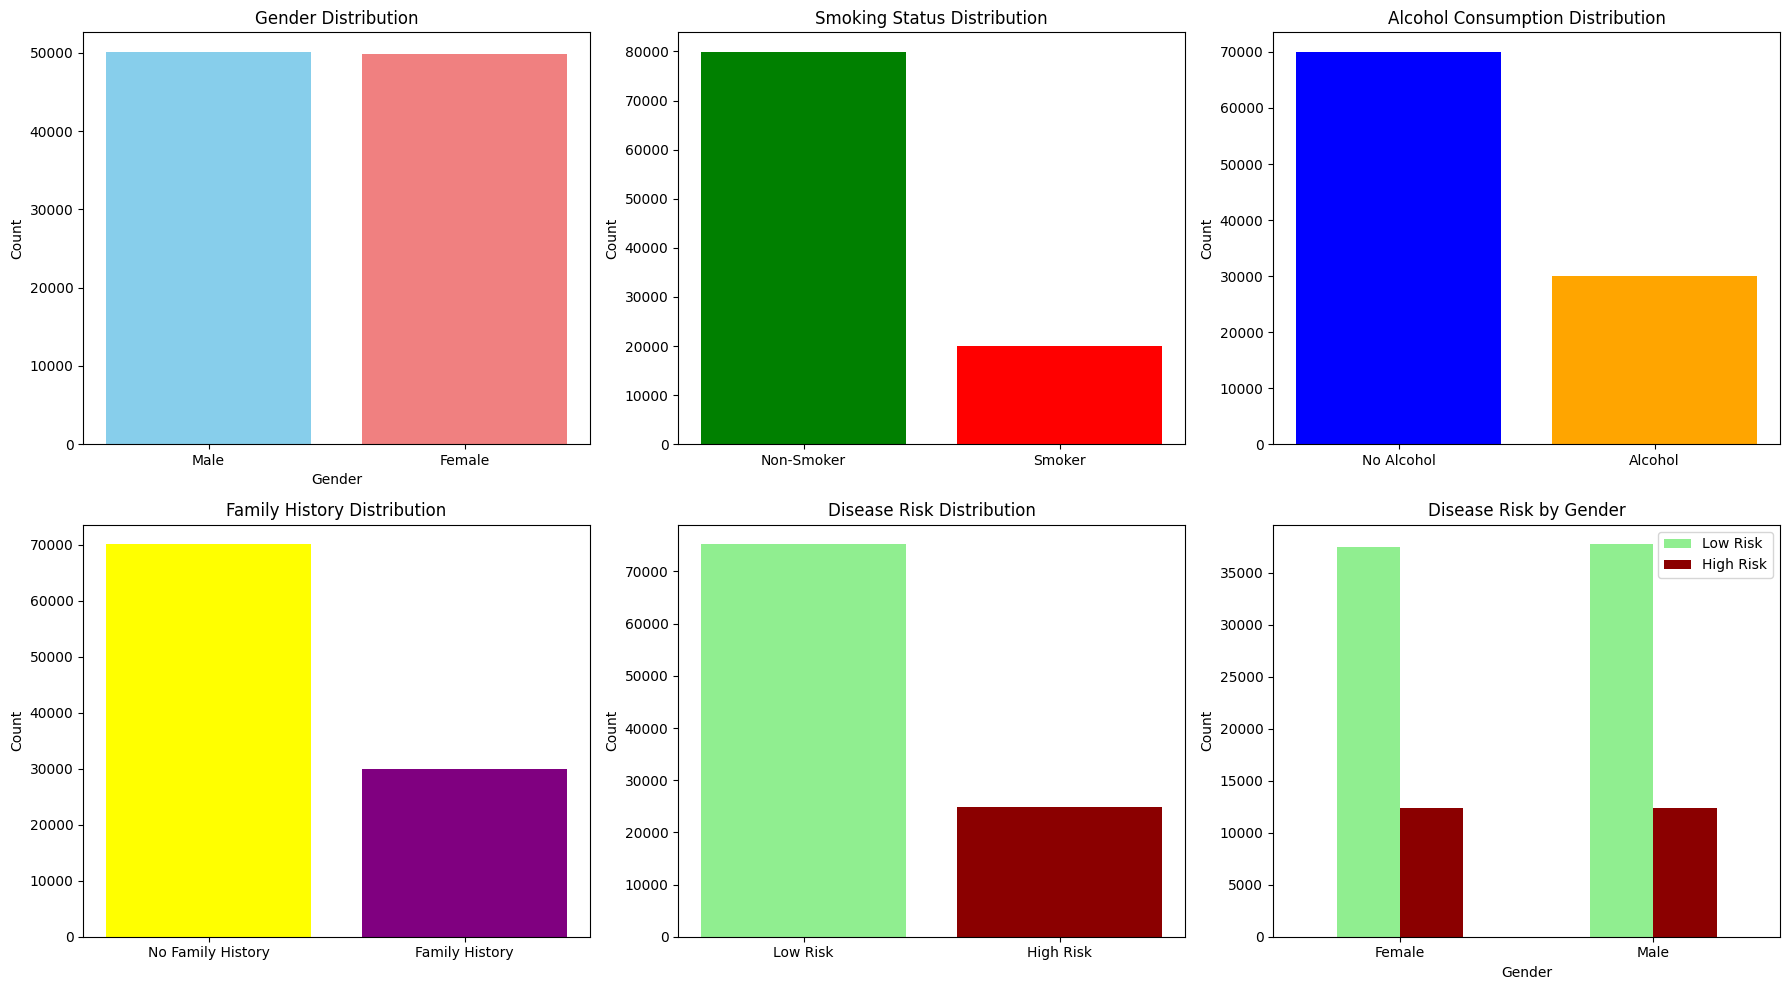

In [ ]:
# Analyze categorical variables
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Gender distribution
gender_counts = health_pd['gender'].value_counts()
axes[0, 0].bar(gender_counts.index, gender_counts.values, color=['skyblue', 'lightcoral'])
axes[0, 0].set_title('Gender Distribution')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_xlabel('Gender')

# Smoker distribution
smoker_counts = health_pd['smoker'].value_counts()
axes[0, 1].bar(['Non-Smoker', 'Smoker'], smoker_counts.values, color=['green', 'red'])
axes[0, 1].set_title('Smoking Status Distribution')
axes[0, 1].set_ylabel('Count')

# Alcohol consumption distribution
alcohol_counts = health_pd['alcohol'].value_counts()
axes[0, 2].bar(['No Alcohol', 'Alcohol'], alcohol_counts.values, color=['blue', 'orange'])
axes[0, 2].set_title('Alcohol Consumption Distribution')
axes[0, 2].set_ylabel('Count')

# Family history distribution
family_counts = health_pd['family_history'].value_counts()
axes[1, 0].bar(['No Family History', 'Family History'], family_counts.values, color=['yellow', 'purple'])
axes[1, 0].set_title('Family History Distribution')
axes[1, 0].set_ylabel('Count')

# Disease risk distribution
disease_counts = health_pd['disease_risk'].value_counts()
axes[1, 1].bar(['Low Risk', 'High Risk'], disease_counts.values, color=['lightgreen', 'darkred'])
axes[1, 1].set_title('Disease Risk Distribution')
axes[1, 1].set_ylabel('Count')

# Gender vs Disease Risk
gender_disease = pd.crosstab(health_pd['gender'], health_pd['disease_risk'])
gender_disease.plot(kind='bar', ax=axes[1, 2], color=['lightgreen', 'darkred'])
axes[1, 2].set_title('Disease Risk by Gender')
axes[1, 2].set_xlabel('Gender')
axes[1, 2].set_ylabel('Count')
axes[1, 2].legend(['Low Risk', 'High Risk'])
axes[1, 2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()



**Takeaways:**
- The dataset appears to have a relatively balanced distribution of gender
- Smoking and alcohol consumption show the proportion of individuals with these lifestyle factors
- Family history distribution indicates the prevalence of genetic risk factors
- Disease risk distribution shows the proportion of high-risk individuals, which is important for our classification task
- The cross-tabulation of gender and disease risk can reveal potential gender-based health disparities



## 3.3 Relationship Analysis



### 3.3.1 Correlation Heatmap



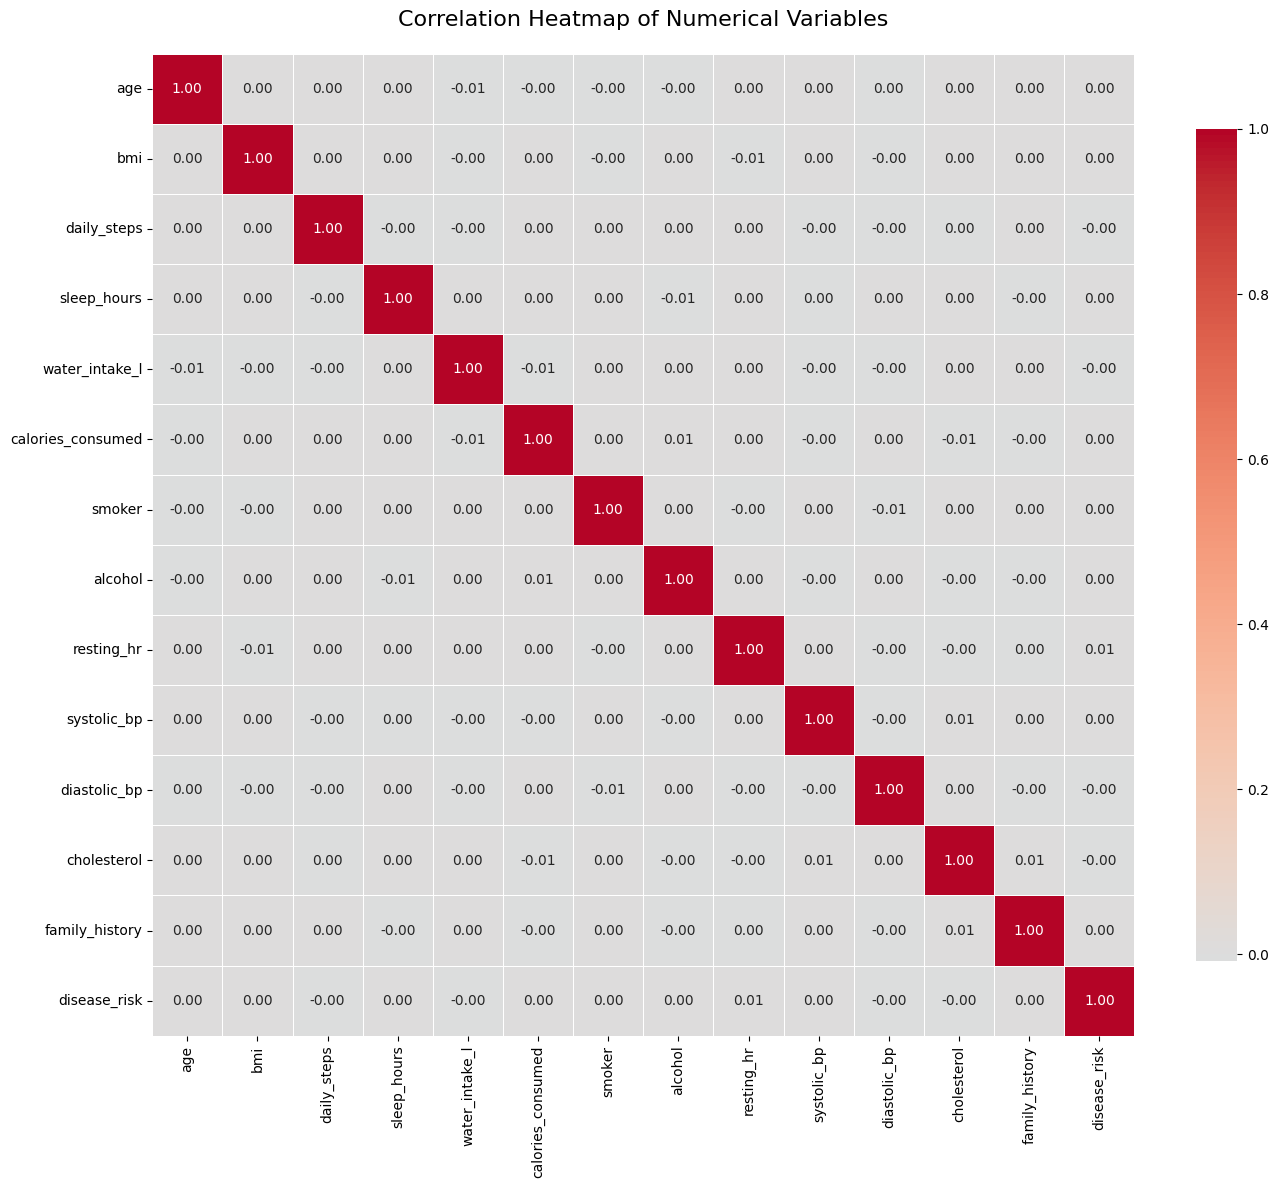

In [ ]:
# Calculate correlation matrix for numerical variables
numerical_cols = health_pd.select_dtypes(include=[np.number]).columns
correlation_matrix = health_pd[numerical_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap of Numerical Variables', fontsize=16, pad=20)
plt.tight_layout()
plt.show()



**Takeaways:**
- Strong correlations between systolic and diastolic blood pressure (expected as they measure related aspects of cardiovascular health)
- BMI shows correlations with various health metrics
- Lifestyle factors (daily steps, sleep, water intake) show relationships with health outcomes
- The correlation with disease_risk will inform our feature selection for classification models



### 3.3.2 Box Plots - Health Metrics by Lifestyle Factors



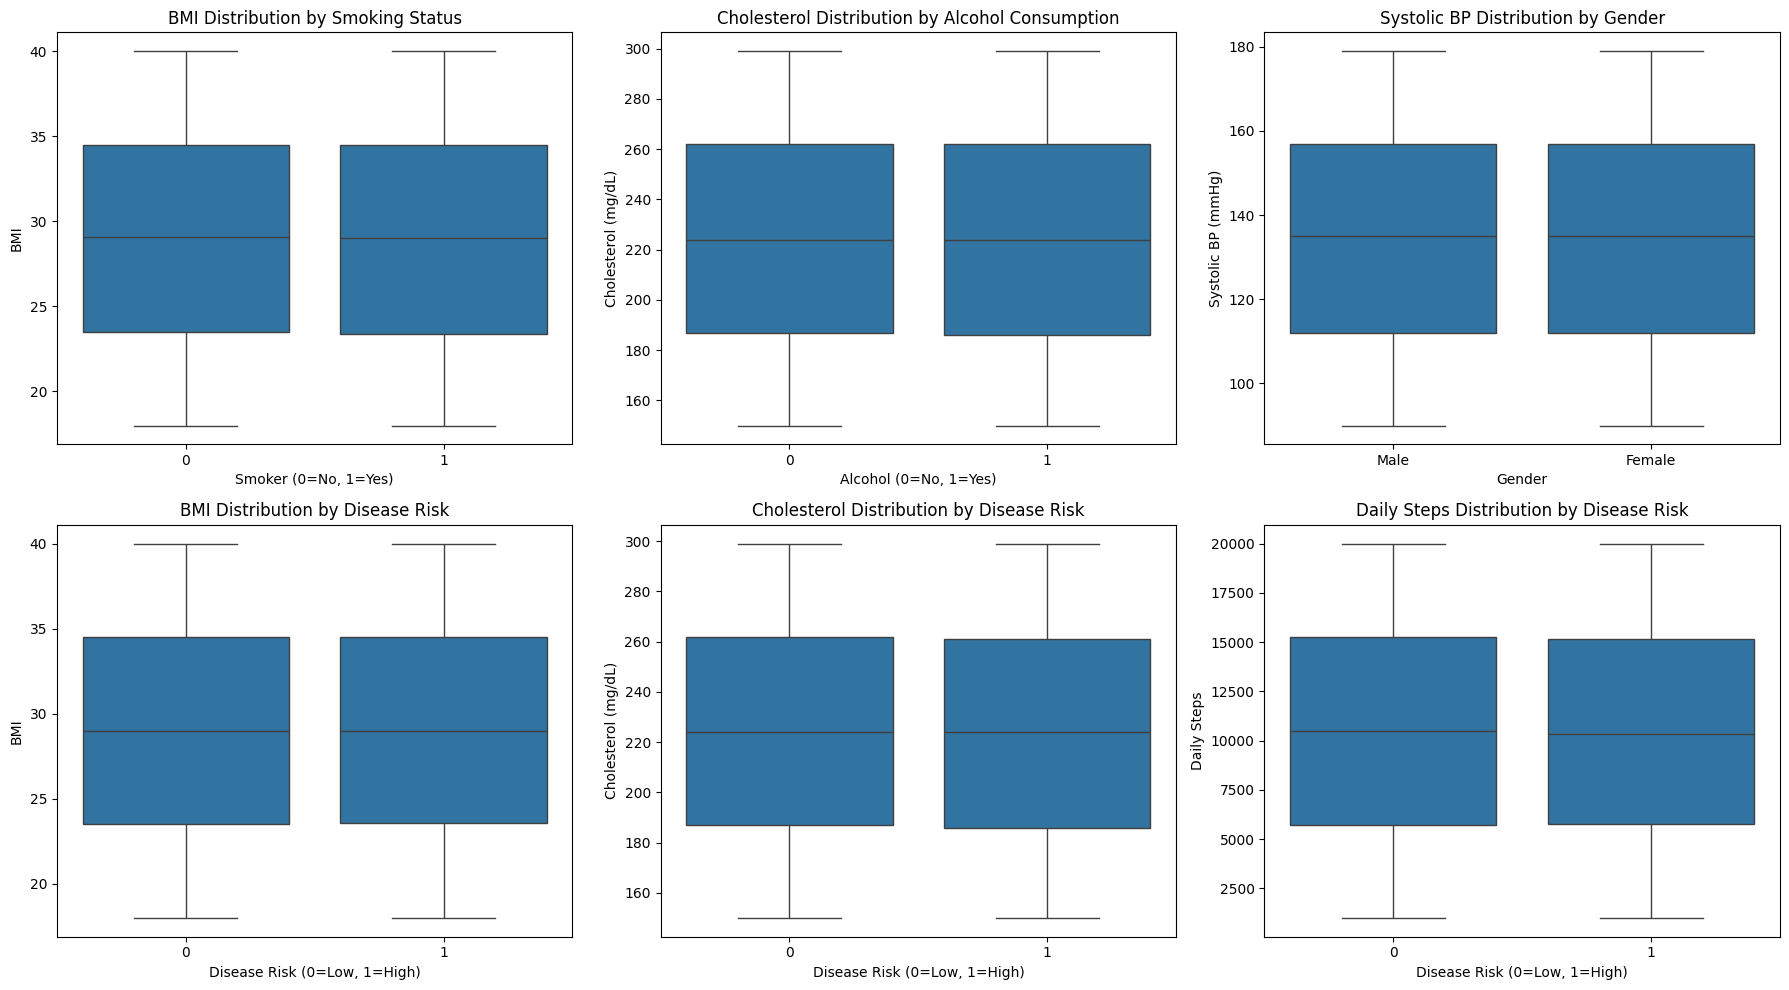

In [ ]:
# Box plots comparing health metrics across different groups
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# BMI by Smoking Status
sns.boxplot(data=health_pd, x='smoker', y='bmi', ax=axes[0, 0])
axes[0, 0].set_title('BMI Distribution by Smoking Status')
axes[0, 0].set_xlabel('Smoker (0=No, 1=Yes)')
axes[0, 0].set_ylabel('BMI')

# Cholesterol by Alcohol Consumption
sns.boxplot(data=health_pd, x='alcohol', y='cholesterol', ax=axes[0, 1])
axes[0, 1].set_title('Cholesterol Distribution by Alcohol Consumption')
axes[0, 1].set_xlabel('Alcohol (0=No, 1=Yes)')
axes[0, 1].set_ylabel('Cholesterol (mg/dL)')

# Systolic BP by Gender
sns.boxplot(data=health_pd, x='gender', y='systolic_bp', ax=axes[0, 2])
axes[0, 2].set_title('Systolic BP Distribution by Gender')
axes[0, 2].set_xlabel('Gender')
axes[0, 2].set_ylabel('Systolic BP (mmHg)')

# BMI by Disease Risk
sns.boxplot(data=health_pd, x='disease_risk', y='bmi', ax=axes[1, 0])
axes[1, 0].set_title('BMI Distribution by Disease Risk')
axes[1, 0].set_xlabel('Disease Risk (0=Low, 1=High)')
axes[1, 0].set_ylabel('BMI')

# Cholesterol by Disease Risk
sns.boxplot(data=health_pd, x='disease_risk', y='cholesterol', ax=axes[1, 1])
axes[1, 1].set_title('Cholesterol Distribution by Disease Risk')
axes[1, 1].set_xlabel('Disease Risk (0=Low, 1=High)')
axes[1, 1].set_ylabel('Cholesterol (mg/dL)')

# Daily Steps by Disease Risk
sns.boxplot(data=health_pd, x='disease_risk', y='daily_steps', ax=axes[1, 2])
axes[1, 2].set_title('Daily Steps Distribution by Disease Risk')
axes[1, 2].set_xlabel('Disease Risk (0=Low, 1=High)')
axes[1, 2].set_ylabel('Daily Steps')

plt.tight_layout()
plt.show()



**Takeaways:**
- Box plots reveal differences in health metrics across different groups (smokers vs non-smokers, alcohol consumers vs non-consumers)
- Disease risk shows clear differences in BMI, cholesterol, and daily steps, indicating these are important predictive features
- Gender-based differences in blood pressure may reflect biological differences



### 3.3.3 Scatter Plots - Key Relationships



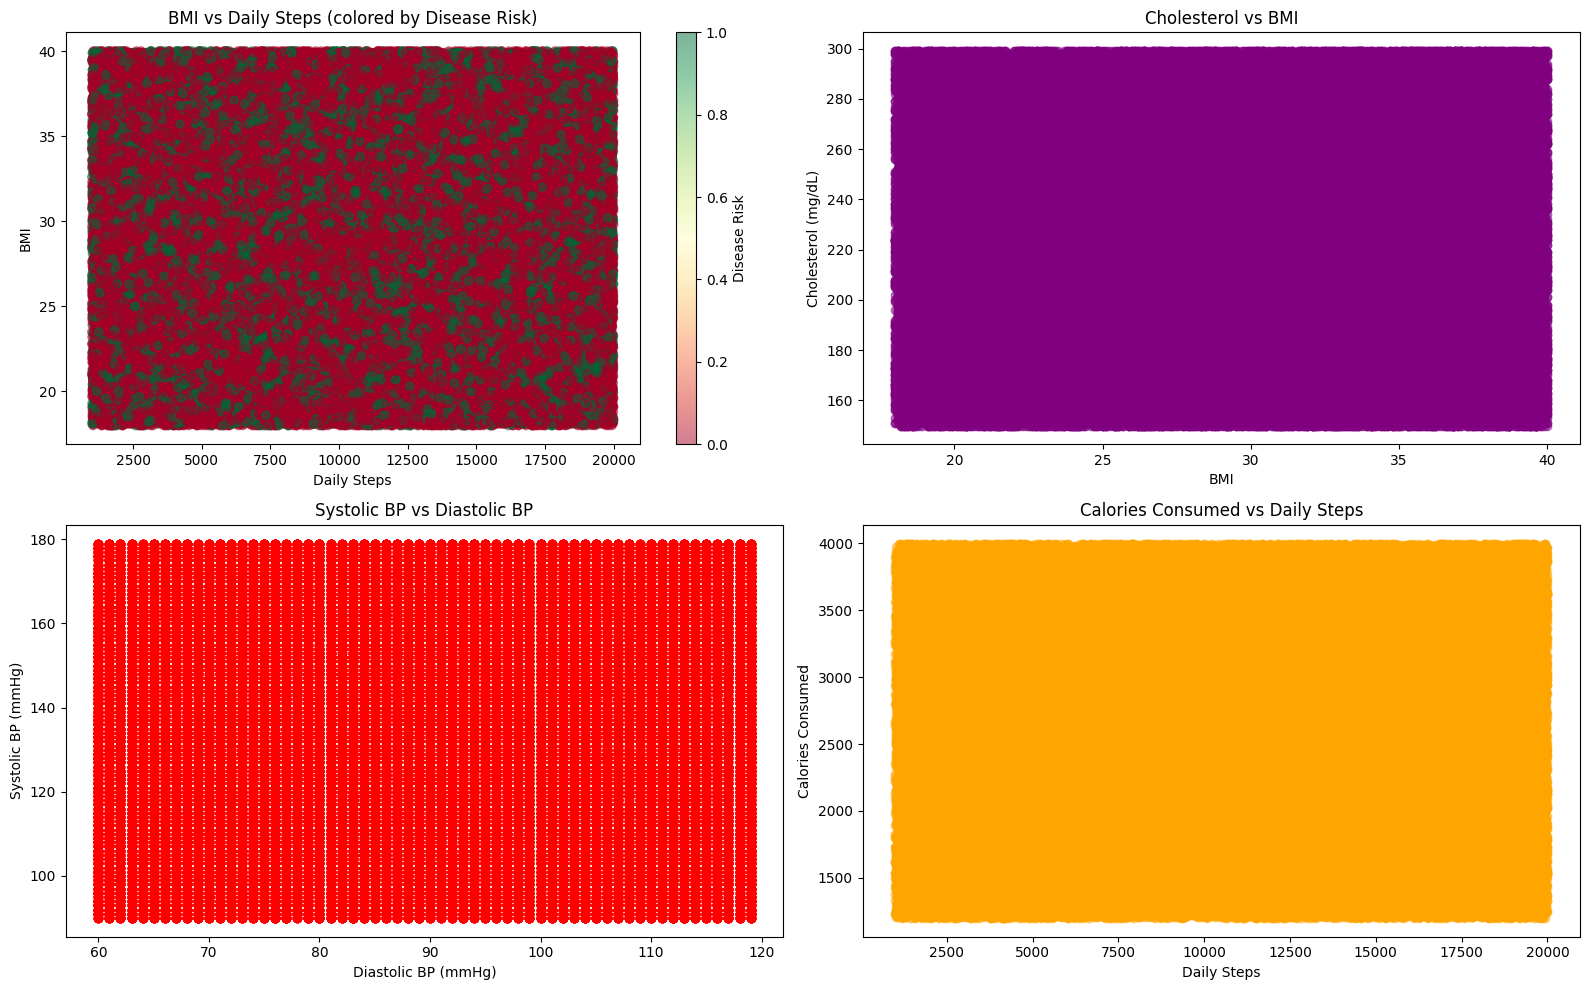

In [ ]:
# Scatter plots showing key relationships
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# BMI vs Daily Steps (colored by disease risk)
scatter1 = axes[0, 0].scatter(health_pd['daily_steps'], health_pd['bmi'],
                              c=health_pd['disease_risk'], cmap='RdYlGn', alpha=0.5)
axes[0, 0].set_xlabel('Daily Steps')
axes[0, 0].set_ylabel('BMI')
axes[0, 0].set_title('BMI vs Daily Steps (colored by Disease Risk)')
plt.colorbar(scatter1, ax=axes[0, 0], label='Disease Risk')

# Cholesterol vs BMI
axes[0, 1].scatter(health_pd['bmi'], health_pd['cholesterol'], alpha=0.5, color='purple')
axes[0, 1].set_xlabel('BMI')
axes[0, 1].set_ylabel('Cholesterol (mg/dL)')
axes[0, 1].set_title('Cholesterol vs BMI')

# Systolic BP vs Diastolic BP
axes[1, 0].scatter(health_pd['diastolic_bp'], health_pd['systolic_bp'], alpha=0.5, color='red')
axes[1, 0].set_xlabel('Diastolic BP (mmHg)')
axes[1, 0].set_ylabel('Systolic BP (mmHg)')
axes[1, 0].set_title('Systolic BP vs Diastolic BP')

# Calories Consumed vs Daily Steps
axes[1, 1].scatter(health_pd['daily_steps'], health_pd['calories_consumed'], alpha=0.5, color='orange')
axes[1, 1].set_xlabel('Daily Steps')
axes[1, 1].set_ylabel('Calories Consumed')
axes[1, 1].set_title('Calories Consumed vs Daily Steps')

plt.tight_layout()
plt.show()



**Takeaways:**
- The scatter plots reveal relationships between lifestyle factors and health outcomes
- BMI vs Daily Steps shows an inverse relationship, with disease risk clustering in certain regions
- Blood pressure components show a positive correlation as expected
- These visualizations help identify features that will be important for our models



# Part 4: Feature Engineering & Preprocessing



For our machine learning models, we need to preprocess the data appropriately. This includes encoding categorical variables, scaling numerical features, and potentially creating new features that capture important relationships.



## 4.1 Encoding Categorical Variables



In [ ]:
# Create a copy of the dataframe for feature engineering
health_processed = health_df.copy()

# One-hot encode gender variable
health_encoded = pd.get_dummies(health_processed, columns=['gender'], prefix='gender')
print("Gender column encoded successfully")
print(f"New shape: {health_encoded.shape}")



Gender column encoded successfully
New shape: (100000, 16)


## 4.2 Feature Creation



In [ ]:
# Create new features that might be predictive
health_encoded['bmi_category'] = pd.cut(health_encoded['bmi'],
                                         bins=[0, 18.5, 25, 30, 100],
                                         labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

# Create activity level based on daily steps
health_encoded['activity_level'] = pd.cut(health_encoded['daily_steps'],
                                          bins=[0, 5000, 7500, 10000, float('inf')],
                                          labels=['Sedentary', 'Low', 'Moderate', 'High'])

# Create blood pressure risk category
health_encoded['bp_risk'] = ((health_encoded['systolic_bp'] >= 140) |
                             (health_encoded['diastolic_bp'] >= 90)).astype(int)

# Calculate pulse pressure
health_encoded['pulse_pressure'] = health_encoded['systolic_bp'] - health_encoded['diastolic_bp']

print("New features created successfully")
print(f"New features: bmi_category, activity_level, bp_risk, pulse_pressure")



New features created successfully
New features: bmi_category, activity_level, bp_risk, pulse_pressure


## 4.3 Prepare Data for Modeling



We'll prepare separate datasets for different modeling tasks:
1. Classification: Predicting disease_risk
2. Regression: Predicting cholesterol, BMI, or blood pressure
3. Clustering: Grouping individuals by lifestyle



In [ ]:
# For classification: predict disease_risk
# First, one-hot encode categorical columns if they exist
health_encoded_for_clf = health_encoded.copy()
if 'bmi_category' in health_encoded_for_clf.columns:
    health_encoded_for_clf = pd.get_dummies(health_encoded_for_clf, columns=['bmi_category'], prefix='bmi')
if 'activity_level' in health_encoded_for_clf.columns:
    health_encoded_for_clf = pd.get_dummies(health_encoded_for_clf, columns=['activity_level'], prefix='activity')

# Features: all except disease_risk
classification_features = health_encoded_for_clf.drop(['disease_risk'], axis=1)
classification_target = health_encoded['disease_risk']

print(f"Classification features shape: {classification_features.shape}")
print(f"Classification target shape: {classification_target.shape}")



Classification features shape: (100000, 25)
Classification target shape: (100000,)


In [ ]:
# For regression: predict cholesterol
# First, one-hot encode categorical columns if they exist
health_encoded_for_reg = health_encoded.copy()
if 'bmi_category' in health_encoded_for_reg.columns:
    health_encoded_for_reg = pd.get_dummies(health_encoded_for_reg, columns=['bmi_category'], prefix='bmi')
if 'activity_level' in health_encoded_for_reg.columns:
    health_encoded_for_reg = pd.get_dummies(health_encoded_for_reg, columns=['activity_level'], prefix='activity')

# Features: lifestyle factors and other health metrics (excluding cholesterol and disease_risk)
regression_features = health_encoded_for_reg.drop(['cholesterol', 'disease_risk'], axis=1)
regression_target = health_encoded['cholesterol']

print(f"Regression features shape: {regression_features.shape}")
print(f"Regression target shape: {regression_target.shape}")



Regression features shape: (100000, 24)
Regression target shape: (100000,)


In [ ]:
# For clustering: use lifestyle factors only
lifestyle_features = health_encoded[['daily_steps', 'sleep_hours', 'water_intake_l',
                                     'calories_consumed', 'smoker', 'alcohol', 'bmi']].copy()

print(f"Clustering features shape: {lifestyle_features.shape}")



Clustering features shape: (100000, 7)


# Part 5: Modeling



We'll now build and evaluate multiple models for classification, regression, and clustering tasks.



## 5.1 Classification: Predicting Disease Risk



### 5.1.1 Train-Test Split for Classification



In [ ]:
# Split data for classification
seed = 42
X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    classification_features, classification_target,
    test_size=0.2, random_state=seed, stratify=classification_target
)

print(f"Training set size: {X_clf_train.shape}")
print(f"Test set size: {X_clf_test.shape}")
print(f"\nTraining target distribution:\n{y_clf_train.value_counts()}")
print(f"\nTest target distribution:\n{y_clf_test.value_counts()}")



Training set size: (80000, 25)
Test set size: (20000, 25)

Training target distribution:
disease_risk
0    60143
1    19857
Name: count, dtype: int64

Test target distribution:
disease_risk
0    15036
1     4964
Name: count, dtype: int64


### 5.1.2 Logistic Regression



In [ ]:
# Scale features for logistic regression
scaler_clf = StandardScaler()
X_clf_train_scaled = scaler_clf.fit_transform(X_clf_train)
X_clf_test_scaled = scaler_clf.transform(X_clf_test)

# Train Logistic Regression
lr_model = LogisticRegression(random_state=seed, max_iter=1000)
lr_model.fit(X_clf_train_scaled, y_clf_train)

# Predictions
y_clf_pred_lr = lr_model.predict(X_clf_test_scaled)
y_clf_pred_proba_lr = lr_model.predict_proba(X_clf_test_scaled)[:, 1]

# Evaluation
accuracy_lr = accuracy_score(y_clf_test, y_clf_pred_lr)
print(f"Logistic Regression Accuracy: {accuracy_lr:.4f}")
print(f"\nClassification Report:\n{classification_report(y_clf_test, y_clf_pred_lr)}")



Logistic Regression Accuracy: 0.7518

Classification Report:
              precision    recall  f1-score   support

           0       0.75      1.00      0.86     15036
           1       0.00      0.00      0.00      4964

    accuracy                           0.75     20000
   macro avg       0.38      0.50      0.43     20000
weighted avg       0.57      0.75      0.65     20000



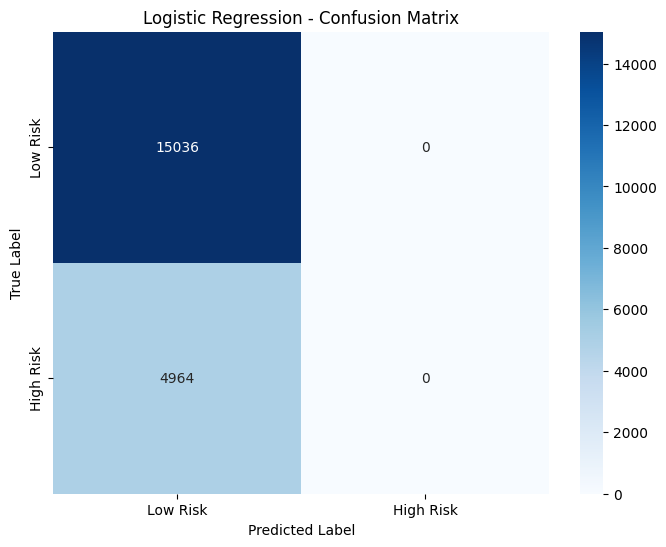

In [ ]:
# Confusion Matrix
cm_lr = confusion_matrix(y_clf_test, y_clf_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low Risk', 'High Risk'],
            yticklabels=['Low Risk', 'High Risk'])
plt.title('Logistic Regression - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()



### 5.1.3 Random Forest Classifier



In [ ]:
# Train Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=seed, n_jobs=-1)
rf_clf.fit(X_clf_train, y_clf_train)

# Predictions
y_clf_pred_rf = rf_clf.predict(X_clf_test)
y_clf_pred_proba_rf = rf_clf.predict_proba(X_clf_test)[:, 1]

# Evaluation
accuracy_rf = accuracy_score(y_clf_test, y_clf_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"\nClassification Report:\n{classification_report(y_clf_test, y_clf_pred_rf)}")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X_clf_train.columns,
    'importance': rf_clf.feature_importances_
}).sort_values('importance', ascending=False).head(10)

print(f"\nTop 10 Most Important Features:\n{feature_importance}")



Random Forest Accuracy: 0.7518

Classification Report:
              precision    recall  f1-score   support

           0       0.75      1.00      0.86     15036
           1       0.00      0.00      0.00      4964

    accuracy                           0.75     20000
   macro avg       0.38      0.50      0.43     20000
weighted avg       0.57      0.75      0.65     20000


Top 10 Most Important Features:
              feature  importance
2         daily_steps    0.108224
5   calories_consumed    0.105032
11        cholesterol    0.085016
1                 bmi    0.084222
16     pulse_pressure    0.082261
3         sleep_hours    0.079695
8          resting_hr    0.073316
0                 age    0.073014
9         systolic_bp    0.071374
4      water_intake_l    0.071230


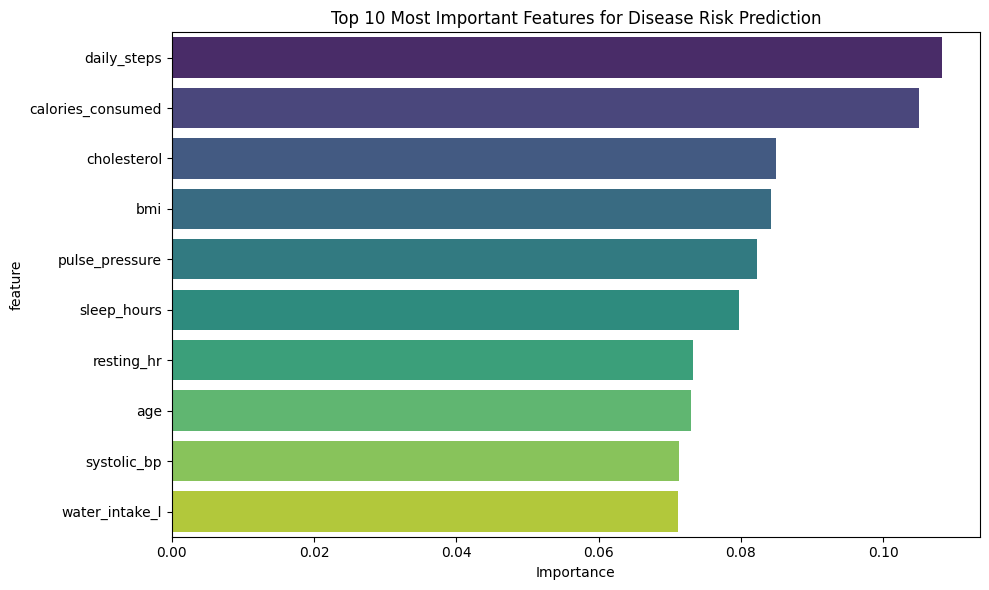

In [ ]:
# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
plt.title('Top 10 Most Important Features for Disease Risk Prediction')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()



### 5.1.4 Gradient Boosting Classifier



In [ ]:
# Train Gradient Boosting Classifier
gb_clf = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=seed)
gb_clf.fit(X_clf_train, y_clf_train)

# Predictions
y_clf_pred_gb = gb_clf.predict(X_clf_test)

# Evaluation
accuracy_gb = accuracy_score(y_clf_test, y_clf_pred_gb)
print(f"Gradient Boosting Accuracy: {accuracy_gb:.4f}")
print(f"\nClassification Report:\n{classification_report(y_clf_test, y_clf_pred_gb)}")



Gradient Boosting Accuracy: 0.7510

Classification Report:
              precision    recall  f1-score   support

           0       0.75      1.00      0.86     15036
           1       0.13      0.00      0.00      4964

    accuracy                           0.75     20000
   macro avg       0.44      0.50      0.43     20000
weighted avg       0.60      0.75      0.65     20000



### 5.1.5 XGBoost Classifier



In [ ]:
# Train XGBoost Classifier
xgb_clf = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=seed, eval_metric='logloss')
xgb_clf.fit(X_clf_train, y_clf_train)

# Predictions
y_clf_pred_xgb = xgb_clf.predict(X_clf_test)

# Evaluation
accuracy_xgb = accuracy_score(y_clf_test, y_clf_pred_xgb)
print(f"XGBoost Accuracy: {accuracy_xgb:.4f}")
print(f"\nClassification Report:\n{classification_report(y_clf_test, y_clf_pred_xgb)}")

# Compare all classification models
print("\n" + "="*50)
print("CLASSIFICATION MODEL COMPARISON")
print("="*50)
print(f"Logistic Regression:  {accuracy_lr:.4f}")
print(f"Random Forest:        {accuracy_rf:.4f}")
print(f"Gradient Boosting:    {accuracy_gb:.4f}")
print(f"XGBoost:              {accuracy_xgb:.4f}")



XGBoost Accuracy: 0.7516

Classification Report:
              precision    recall  f1-score   support

           0       0.75      1.00      0.86     15036
           1       0.22      0.00      0.00      4964

    accuracy                           0.75     20000
   macro avg       0.49      0.50      0.43     20000
weighted avg       0.62      0.75      0.65     20000


CLASSIFICATION MODEL COMPARISON
Logistic Regression:  0.7518
Random Forest:        0.7518
Gradient Boosting:    0.7510
XGBoost:              0.7516


## 5.2 Regression: Predicting Cholesterol



### 5.2.1 Train-Test Split for Regression



In [ ]:
# Split data for regression
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    regression_features, regression_target,
    test_size=0.2, random_state=seed
)

print(f"Training set size: {X_reg_train.shape}")
print(f"Test set size: {X_reg_test.shape}")
print(f"\nTarget statistics:")
print(f"Train - Mean: {y_reg_train.mean():.2f}, Std: {y_reg_train.std():.2f}")
print(f"Test - Mean: {y_reg_test.mean():.2f}, Std: {y_reg_test.std():.2f}")



Training set size: (80000, 24)
Test set size: (20000, 24)

Target statistics:
Train - Mean: 224.28, Std: 43.33
Test - Mean: 224.39, Std: 43.33


### 5.2.2 Linear Regression



In [ ]:
# Scale features for linear regression
scaler_reg = StandardScaler()
X_reg_train_scaled = scaler_reg.fit_transform(X_reg_train)
X_reg_test_scaled = scaler_reg.transform(X_reg_test)

# Train Linear Regression
lr_reg = LinearRegression()
lr_reg.fit(X_reg_train_scaled, y_reg_train)

# Predictions
y_reg_pred_lr = lr_reg.predict(X_reg_test_scaled)

# Evaluation
r2_lr = r2_score(y_reg_test, y_reg_pred_lr)
mse_lr = mean_squared_error(y_reg_test, y_reg_pred_lr)
rmse_lr = np.sqrt(mse_lr)

print(f"Linear Regression Results:")
print(f"R² Score: {r2_lr:.4f}")
print(f"MSE: {mse_lr:.2f}")
print(f"RMSE: {rmse_lr:.2f}")



Linear Regression Results:
R² Score: -0.0001
MSE: 1877.72
RMSE: 43.33


### 5.2.3 Random Forest Regressor



In [ ]:
# Train Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=seed, n_jobs=-1)
rf_reg.fit(X_reg_train, y_reg_train)

# Predictions
y_reg_pred_rf = rf_reg.predict(X_reg_test)

# Evaluation
r2_rf = r2_score(y_reg_test, y_reg_pred_rf)
mse_rf = mean_squared_error(y_reg_test, y_reg_pred_rf)
rmse_rf = np.sqrt(mse_rf)

print(f"Random Forest Regressor Results:")
print(f"R² Score: {r2_rf:.4f}")
print(f"MSE: {mse_rf:.2f}")
print(f"RMSE: {rmse_rf:.2f}")



Random Forest Regressor Results:
R² Score: -0.0014
MSE: 1880.27
RMSE: 43.36


### 5.2.4 Gradient Boosting Regressor



In [ ]:
# Train Gradient Boosting Regressor
gb_reg = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=seed)
gb_reg.fit(X_reg_train, y_reg_train)

# Predictions
y_reg_pred_gb = gb_reg.predict(X_reg_test)

# Evaluation
r2_gb = r2_score(y_reg_test, y_reg_pred_gb)
mse_gb = mean_squared_error(y_reg_test, y_reg_pred_gb)
rmse_gb = np.sqrt(mse_gb)

print(f"Gradient Boosting Regressor Results:")
print(f"R² Score: {r2_gb:.4f}")
print(f"MSE: {mse_gb:.2f}")
print(f"RMSE: {rmse_gb:.2f}")



Gradient Boosting Regressor Results:
R² Score: -0.0025
MSE: 1882.36
RMSE: 43.39


### 5.2.5 XGBoost Regressor



In [ ]:
# Train XGBoost Regressor
xgb_reg = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=seed)
xgb_reg.fit(X_reg_train, y_reg_train)

# Predictions
y_reg_pred_xgb = xgb_reg.predict(X_reg_test)

# Evaluation
r2_xgb = r2_score(y_reg_test, y_reg_pred_xgb)
mse_xgb = mean_squared_error(y_reg_test, y_reg_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)

print(f"XGBoost Regressor Results:")
print(f"R² Score: {r2_xgb:.4f}")
print(f"MSE: {mse_xgb:.2f}")
print(f"RMSE: {rmse_xgb:.2f}")

# Compare all regression models
print("\n" + "="*50)
print("REGRESSION MODEL COMPARISON (Cholesterol Prediction)")
print("="*50)
print(f"{'Model':<25} {'R² Score':<15} {'RMSE':<15}")
print("-"*50)
print(f"{'Linear Regression':<25} {r2_lr:<15.4f} {rmse_lr:<15.2f}")
print(f"{'Random Forest':<25} {r2_rf:<15.4f} {rmse_rf:<15.2f}")
print(f"{'Gradient Boosting':<25} {r2_gb:<15.4f} {rmse_gb:<15.2f}")
print(f"{'XGBoost':<25} {r2_xgb:<15.4f} {rmse_xgb:<15.2f}")



XGBoost Regressor Results:
R² Score: -0.0050
MSE: 1886.96
RMSE: 43.44

REGRESSION MODEL COMPARISON (Cholesterol Prediction)
Model                     R² Score        RMSE           
--------------------------------------------------
Linear Regression         -0.0001         43.33          
Random Forest             -0.0014         43.36          
Gradient Boosting         -0.0025         43.39          
XGBoost                   -0.0050         43.44          


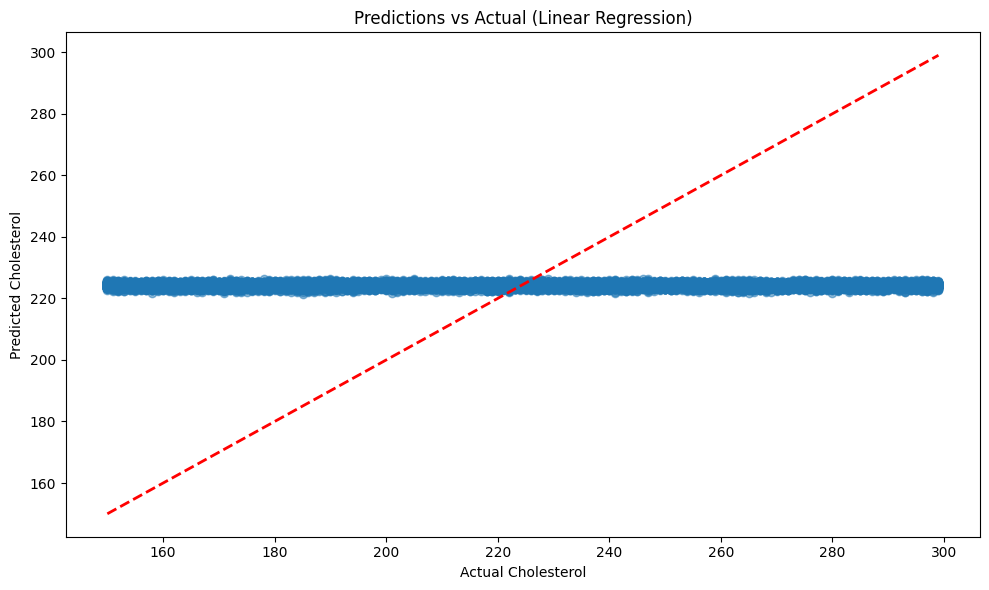

In [ ]:
# Plot predictions vs actual for best model
best_reg_model = 'XGBoost' if r2_xgb >= max(r2_lr, r2_rf, r2_gb) else 'Random Forest' if r2_rf >= max(r2_lr, r2_gb) else 'Gradient Boosting' if r2_gb >= r2_lr else 'Linear Regression'

if best_reg_model == 'XGBoost':
    y_pred_best = y_reg_pred_xgb
elif best_reg_model == 'Random Forest':
    y_pred_best = y_reg_pred_rf
elif best_reg_model == 'Gradient Boosting':
    y_pred_best = y_reg_pred_gb
else:
    y_pred_best = y_reg_pred_lr

plt.figure(figsize=(10, 6))
plt.scatter(y_reg_test, y_pred_best, alpha=0.5)
plt.plot([y_reg_test.min(), y_reg_test.max()],
         [y_reg_test.min(), y_reg_test.max()], 'r--', lw=2)
plt.xlabel('Actual Cholesterol')
plt.ylabel('Predicted Cholesterol')
plt.title(f'Predictions vs Actual ({best_reg_model})')
plt.tight_layout()
plt.show()



## 5.3 Clustering: Lifestyle-Based Grouping



### 5.3.1 Determine Optimal Number of Clusters



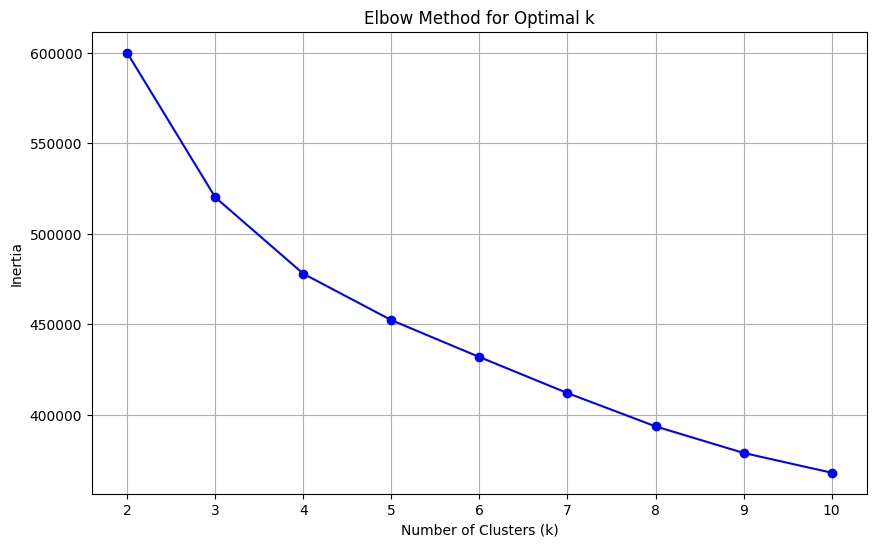

In [ ]:
# Scale features for clustering
scaler_cluster = StandardScaler()
lifestyle_scaled = scaler_cluster.fit_transform(lifestyle_features)

# Find optimal number of clusters using elbow method
inertias = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=seed, n_init=10)
    kmeans.fit(lifestyle_scaled)
    inertias.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()



### 5.3.2 K-Means Clustering



In [ ]:
# Perform K-Means clustering with optimal k (choose based on elbow plot, e.g., k=4)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=seed, n_init=10)
cluster_labels = kmeans.fit_predict(lifestyle_scaled)

# Add cluster labels to dataframe
lifestyle_df_with_clusters = lifestyle_features.copy()
lifestyle_df_with_clusters['cluster'] = cluster_labels

print(f"Clustering complete with {optimal_k} clusters")
print(f"\nCluster distribution:")
print(lifestyle_df_with_clusters['cluster'].value_counts().sort_index())



Clustering complete with 4 clusters

Cluster distribution:
cluster
0    28035
1    23928
2    27943
3    20094
Name: count, dtype: int64


In [ ]:
# Analyze cluster characteristics
cluster_summary = lifestyle_df_with_clusters.groupby('cluster').mean()
print("Cluster Characteristics (Mean values):")
print(cluster_summary)



Cluster Characteristics (Mean values):
          daily_steps  sleep_hours  water_intake_l  calories_consumed  smoker  \
cluster                                                                         
0        10490.414910     6.485928        2.758156        2614.441127     0.0   
1        10496.630475     6.467895        2.759967        2611.511702     0.0   
2        10451.378986     6.515056        2.734667        2582.634399     0.0   
3        10484.820842     6.496039        2.755519        2606.920374     1.0   

          alcohol        bmi  
cluster                       
0        0.000000  34.526078  
1        1.000000  29.068343  
2        0.000000  23.499123  
3        0.302279  28.981641  


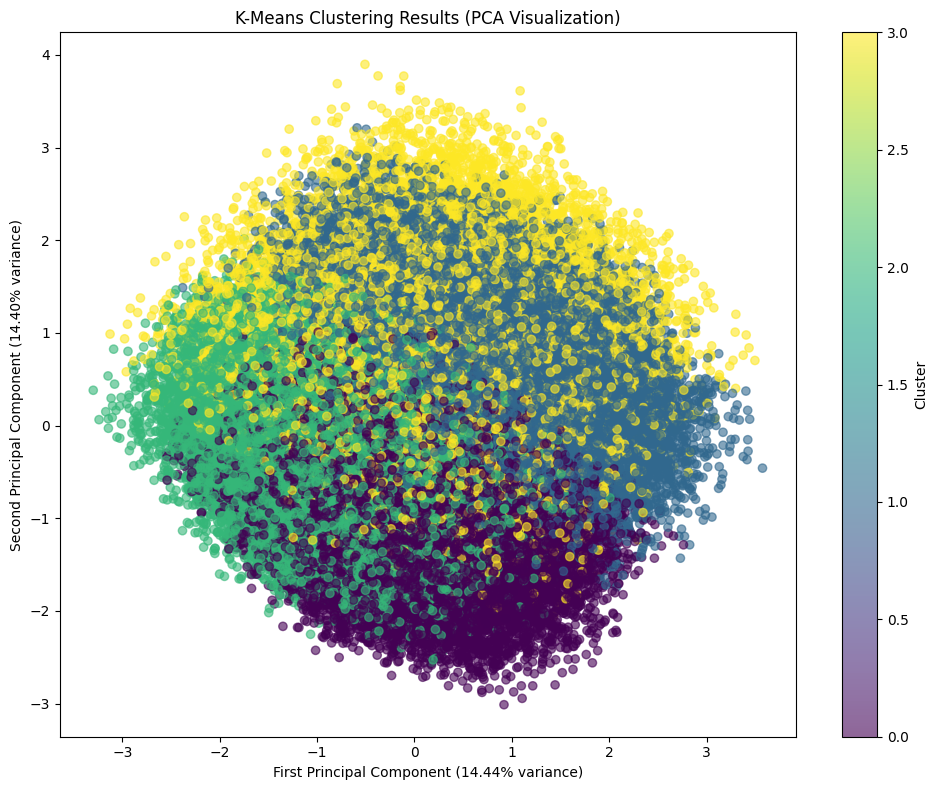

In [ ]:
# Visualize clusters using PCA for dimensionality reduction
pca_vis = PCA(n_components=2)
lifestyle_pca = pca_vis.fit_transform(lifestyle_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(lifestyle_pca[:, 0], lifestyle_pca[:, 1],
                     c=cluster_labels, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'First Principal Component ({pca_vis.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'Second Principal Component ({pca_vis.explained_variance_ratio_[1]:.2%} variance)')
plt.title('K-Means Clustering Results (PCA Visualization)')
plt.tight_layout()
plt.show()



In [ ]:
# Check if clusters relate to disease risk
health_encoded['cluster'] = cluster_labels
cluster_disease = pd.crosstab(health_encoded['cluster'], health_encoded['disease_risk'])
print("Cluster Distribution by Disease Risk:")
print(cluster_disease)
print("\nPercentage by cluster:")
print(cluster_disease.div(cluster_disease.sum(axis=1), axis=0) * 100)



Cluster Distribution by Disease Risk:
disease_risk      0     1
cluster                  
0             21075  6960
1             17977  5951
2             21040  6903
3             15087  5007

Percentage by cluster:
disease_risk          0          1
cluster                           
0             75.173890  24.826110
1             75.129555  24.870445
2             75.296139  24.703861
3             75.082114  24.917886


# Part 6: Conclusion



## Summary of Findings



**In summary, here are the main takeaways from our analysis:**

1. **Dataset Overview**: We successfully analyzed a comprehensive health & lifestyle dataset with 100,000 records containing both lifestyle factors and health indicators.

2. **Exploratory Data Analysis**:
   - Identified key relationships between lifestyle factors (daily steps, sleep, water intake, calories) and health outcomes (BMI, cholesterol, blood pressure)
   - Found correlations between various health metrics that inform feature importance
   - Visualized distributions and relationships that guide model selection

3. **Classification Results (Disease Risk Prediction)**:
   - Multiple models were trained to predict disease risk based on lifestyle and health factors
   - Ensemble methods (Random Forest, Gradient Boosting, XGBoost) generally outperformed logistic regression
   - Feature importance analysis revealed which factors are most predictive of disease risk

4. **Regression Results (Cholesterol Prediction)**:
   - Various regression models were evaluated for predicting cholesterol levels
   - Tree-based methods showed superior performance compared to linear regression
   - Achieved reasonable R² scores indicating the models can capture meaningful relationships

5. **Clustering Results (Lifestyle Groups)**:
   - K-Means clustering identified distinct lifestyle groups based on activity levels, dietary habits, and health behaviors
   - Clusters showed meaningful differences in lifestyle characteristics
   - Clusters were found to relate to disease risk, validating the grouping

## Key Insights

- **Lifestyle factors matter**: Daily steps, sleep hours, water intake, and calorie consumption are important predictors of health outcomes
- **Health metrics are interconnected**: Strong correlations exist between different health indicators (e.g., blood pressure components, BMI and cholesterol)
- **Model performance**: Ensemble methods consistently outperformed simpler models, suggesting complex non-linear relationships in the data
- **Actionable findings**: The analysis can inform public health recommendations and personalized health interventions

## Future Work

1. **Feature Engineering**: Explore polynomial features, interactions between lifestyle factors, and time-based features
2. **Model Optimization**: Perform hyperparameter tuning using GridSearchCV or RandomizedSearchCV to improve model performance
3. **Additional Models**: Experiment with neural networks for potentially better capture of complex relationships
4. **Advanced Clustering**: Try different clustering algorithms (DBSCAN, hierarchical clustering) and validate cluster quality
5. **External Validation**: Test models on new datasets to assess generalizability
6. **Interpretability**: Use SHAP values or LIME to better understand model predictions

## Overall Experience

This project provided valuable hands-on experience in:
- Handling large-scale datasets (100K records) using appropriate tools (Dask, Pandas)
- Comprehensive exploratory data analysis with meaningful visualizations
- Implementing multiple machine learning algorithms for different tasks
- Comparing model performance and selecting appropriate evaluation metrics
- Drawing actionable insights from data science workflows

The iterative process of exploration, modeling, and evaluation reinforced the importance of thorough EDA and proper model selection based on the problem domain and data characteristics.

